<a href="https://colab.research.google.com/github/pozdnyavladimer-jpg/v-kernel/blob/main/notebooks/diffusion_recovery_controller.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

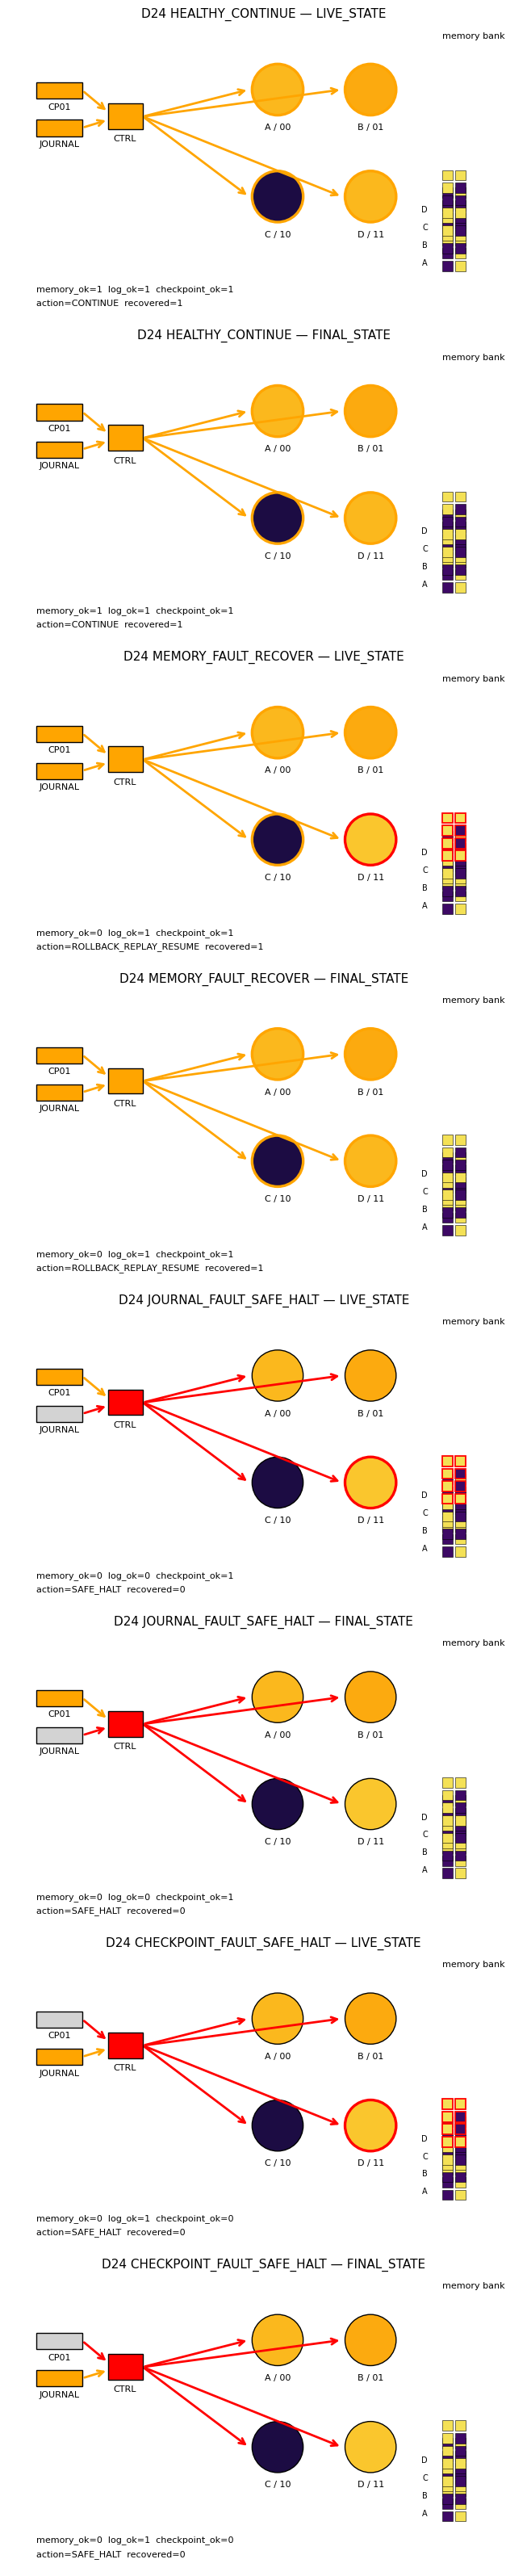

STATE: RECOVERY_CONTROLLER_LOCKED
cases tested:              4
locked cases:              4
checkpoint id:             CP01
checkpoint after tx:       TX01
clean final hash:          a1766a97aacc
checkpoint hash:           e28bf0576a7d

healthy action:            CONTINUE
memory fault action:       ROLLBACK_REPLAY_RESUME
journal broken action:     SAFE_HALT
checkpoint broken action:  SAFE_HALT

Controller decision table:


,STATE,CASE,RESULT,ACTION,MEMORY_OK,LOG_OK,CHECKPOINT_OK,REPLAYED_TX,LIVE_HASH,FINAL_HASH,EXPECTED_CLEAN_HASH,RECOVERED
0,D24_RECOVERY_CONTROLLER,HEALTHY_CONTINUE,CASE_LOCKED,CONTINUE,1,1,1,0,a1766a97aacc,a1766a97aacc,a1766a97aacc,1
1,D24_RECOVERY_CONTROLLER,MEMORY_FAULT_RECOVER,CASE_LOCKED,ROLLBACK_REPLAY_RESUME,0,1,1,2,f599cc9d0415,a1766a97aacc,a1766a97aacc,1
2,D24_RECOVERY_CONTROLLER,JOURNAL_FAULT_SAFE_HALT,CASE_LOCKED,SAFE_HALT,0,0,1,0,f599cc9d0415,f599cc9d0415,a1766a97aacc,0
3,D24_RECOVERY_CONTROLLER,CHECKPOINT_FAULT_SAFE_HALT,CASE_LOCKED,SAFE_HALT,0,1,0,0,f599cc9d0415,f599cc9d0415,a1766a97aacc,0



Per-cell final recovery table:


,STATE,CASE,CELL,LIVE_SEQUENCE,FINAL_SEQUENCE,CLEAN_TARGET,FINAL_MATCH_CLEAN
0,D24_RECOVERY_CONTROLLER,HEALTHY_CONTINUE,MEM_CELL_A,10110101,10110101,10110101,1
1,D24_RECOVERY_CONTROLLER,HEALTHY_CONTINUE,MEM_CELL_B,11001100,11001100,11001100,1
2,D24_RECOVERY_CONTROLLER,HEALTHY_CONTINUE,MEM_CELL_C,01001010,01001010,01001010,1
3,D24_RECOVERY_CONTROLLER,HEALTHY_CONTINUE,MEM_CELL_D,11100011,11100011,11100011,1
4,D24_RECOVERY_CONTROLLER,MEMORY_FAULT_RECOVER,MEM_CELL_A,10110101,10110101,10110101,1
5,D24_RECOVERY_CONTROLLER,MEMORY_FAULT_RECOVER,MEM_CELL_B,11001100,11001100,11001100,1
6,D24_RECOVERY_CONTROLLER,MEMORY_FAULT_RECOVER,MEM_CELL_C,01001010,01001010,01001010,1
7,D24_RECOVERY_CONTROLLER,MEMORY_FAULT_RECOVER,MEM_CELL_D,11101011,11100011,11100011,1
8,D24_RECOVERY_CONTROLLER,JOURNAL_FAULT_SAFE_HALT,MEM_CELL_A,10110101,10110101,10110101,1
9,D24_RECOVERY_CONTROLLER,JOURNAL_FAULT_SAFE_HALT,MEM_CELL_B,11001100,11001100,11001100,1



Clean hash-chain table:


,STATE,TX_ID,EXPECTED_PREV_HASH,LOG_PREV_HASH,EXPECTED_TX_HASH,LOG_TX_HASH,HASH_OK
0,D24_RECOVERY_CONTROLLER,TX00,GENESIS0000,GENESIS0000,68219f775e95,68219f775e95,1
1,D24_RECOVERY_CONTROLLER,TX01,68219f775e95,68219f775e95,658ed4830142,658ed4830142,1
2,D24_RECOVERY_CONTROLLER,TX02,658ed4830142,658ed4830142,588e9b8aa7a3,588e9b8aa7a3,1
3,D24_RECOVERY_CONTROLLER,TX03,588e9b8aa7a3,588e9b8aa7a3,57e41d579965,57e41d579965,1



Summary:


,STATE,RESULT,CASES_TESTED,LOCKED_CASES,CHECKPOINT_ID,CHECKPOINT_AFTER_TX,CLEAN_FINAL_HASH,CHECKPOINT_HASH,HEALTHY_ACTION,MEMORY_FAULT_ACTION,JOURNAL_BROKEN_ACTION,CHECKPOINT_BROKEN_ACTION
0,D24_RECOVERY_CONTROLLER,RECOVERY_CONTROLLER_LOCKED,4,4,CP01,TX01,a1766a97aacc,e28bf0576a7d,CONTINUE,ROLLBACK_REPLAY_RESUME,SAFE_HALT,SAFE_HALT


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import hashlib
from copy import deepcopy
from IPython.display import display
from matplotlib.patches import Circle, Rectangle, FancyArrowPatch

# ============================================================
# D24_RECOVERY_CONTROLLER
# Automatic recovery supervisor for V-Kernel field memory
#
# Goal:
# checkpoint + transaction journal + hash verification
# -> detect healthy memory
# -> detect corrupted memory
# -> rollback to checkpoint
# -> replay valid journal
# -> resume if recovery succeeds
# -> safe halt if journal/checkpoint is broken
# ============================================================

np.random.seed(24)

STATE = "D24_RECOVERY_CONTROLLER"

address_map = {
    "00": "MEM_CELL_A",
    "01": "MEM_CELL_B",
    "10": "MEM_CELL_C",
    "11": "MEM_CELL_D",
}

memory_initial = {
    "MEM_CELL_A": "00000000",
    "MEM_CELL_B": "11111111",
    "MEM_CELL_C": "01001010",
    "MEM_CELL_D": "00110011",
}

transactions = [
    {
        "TX_ID": "TX00",
        "OP": "WRITE",
        "WRITER": "A",
        "ADDR_A": "00",
        "ADDR_B": "",
        "PAYLOAD_A": "10110101",
        "PAYLOAD_B": "",
    },
    {
        "TX_ID": "TX01",
        "OP": "WRITE",
        "WRITER": "B",
        "ADDR_A": "",
        "ADDR_B": "10",
        "PAYLOAD_A": "",
        "PAYLOAD_B": "01001010",
    },
    {
        "TX_ID": "TX02",
        "OP": "WRITE",
        "WRITER": "B",
        "ADDR_A": "",
        "ADDR_B": "01",
        "PAYLOAD_A": "",
        "PAYLOAD_B": "11001100",
    },
    {
        "TX_ID": "TX03",
        "OP": "COLLISION_WRITE",
        "WRITER": "A+B",
        "ADDR_A": "11",
        "ADDR_B": "11",
        "PAYLOAD_A": "11100011",
        "PAYLOAD_B": "00011100",
    },
]

checkpoint_id = "CP01"
checkpoint_after_tx = "TX01"
priority_writer = "A"


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def seq_to_bits(seq):
    return [int(x) for x in seq]


def bits_to_string(bits):
    return "".join(str(int(x)) for x in bits)


def short_hash(text, n=12):
    return hashlib.sha256(text.encode("utf-8")).hexdigest()[:n]


def memory_string(memory):
    return "|".join(f"{cell}:{memory[cell]}" for cell in sorted(memory.keys()))


def memory_hash(memory):
    return short_hash(memory_string(memory))


def flip_bit(seq, index):
    bits = seq_to_bits(seq)
    bits[index] = 1 - bits[index]
    return bits_to_string(bits)


def corrupt_memory(memory, cell, slot):
    corrupted = deepcopy(memory)
    corrupted[cell] = flip_bit(corrupted[cell], slot)
    return corrupted


def selected_cell_for_tx(tx):
    if tx["OP"] == "WRITE":
        if tx["WRITER"] == "A":
            return address_map[tx["ADDR_A"]]
        return address_map[tx["ADDR_B"]]

    if tx["OP"] == "COLLISION_WRITE":
        if tx["ADDR_A"] == tx["ADDR_B"]:
            return address_map[tx["ADDR_A"]]
        return "MULTI_CELL"

    return "NONE"


def tx_hash(prev_hash, record):
    payload = "|".join([
        prev_hash,
        record["TX_ID"],
        record["OP"],
        record["WRITER"],
        record["SELECTED_CELL"],
        record["WINNER"],
        record["BEFORE_SEQUENCE"],
        record["PAYLOAD_WRITTEN"],
        record["AFTER_SEQUENCE"],
        record["RESULT"],
    ])
    return short_hash(payload)


def apply_tx(memory, tx):
    memory = deepcopy(memory)
    selected_cell = selected_cell_for_tx(tx)

    if tx["OP"] == "WRITE":
        winner = tx["WRITER"]
        payload = tx["PAYLOAD_A"] if winner == "A" else tx["PAYLOAD_B"]
        before = memory[selected_cell]
        memory[selected_cell] = payload
        after = memory[selected_cell]
        result = "COMMITTED"

    elif tx["OP"] == "COLLISION_WRITE":
        winner = priority_writer
        payload = tx["PAYLOAD_A"] if winner == "A" else tx["PAYLOAD_B"]
        before = memory[selected_cell]
        memory[selected_cell] = payload
        after = memory[selected_cell]
        result = "COLLISION_ARBITRATED"

    else:
        winner = "NONE"
        payload = ""
        before = ""
        after = ""
        result = "IGNORED"

    record = {
        "TX_ID": tx["TX_ID"],
        "OP": tx["OP"],
        "WRITER": tx["WRITER"],
        "ADDR_A": tx["ADDR_A"],
        "ADDR_B": tx["ADDR_B"],
        "SELECTED_CELL": selected_cell,
        "WINNER": winner,
        "BEFORE_SEQUENCE": before,
        "PAYLOAD_WRITTEN": payload,
        "AFTER_SEQUENCE": after,
        "RESULT": result,
    }

    return memory, record


# ------------------------------------------------------------
# Build clean reference state
# ------------------------------------------------------------

def build_clean_log_and_checkpoint():
    memory = deepcopy(memory_initial)
    log = []
    checkpoints = {}

    prev_hash = "GENESIS0000"

    for tx in transactions:
        memory, record = apply_tx(memory, tx)

        record["PREV_HASH"] = prev_hash
        record["TX_HASH"] = tx_hash(prev_hash, record)

        prev_hash = record["TX_HASH"]
        log.append(record)

        if tx["TX_ID"] == checkpoint_after_tx:
            cp_memory = deepcopy(memory)
            checkpoints[checkpoint_id] = {
                "CHECKPOINT_ID": checkpoint_id,
                "AFTER_TX": tx["TX_ID"],
                "MEMORY": cp_memory,
                "CHECKPOINT_HASH": memory_hash(cp_memory),
                "LOG_HASH_AT_CHECKPOINT": prev_hash,
            }

    return memory, log, checkpoints


clean_final_memory, clean_log, clean_checkpoints = build_clean_log_and_checkpoint()
clean_final_hash = memory_hash(clean_final_memory)
checkpoint_hash = clean_checkpoints[checkpoint_id]["CHECKPOINT_HASH"]


# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

def verify_log_hash_chain(log):
    rows = []
    prev_hash = "GENESIS0000"
    all_ok = True

    for record in log:
        expected_prev = prev_hash
        expected_tx_hash = tx_hash(expected_prev, record)

        prev_ok = record["PREV_HASH"] == expected_prev
        hash_ok = record["TX_HASH"] == expected_tx_hash
        tx_ok = prev_ok and hash_ok

        all_ok = all_ok and tx_ok

        rows.append({
            "STATE": STATE,
            "TX_ID": record["TX_ID"],
            "EXPECTED_PREV_HASH": expected_prev,
            "LOG_PREV_HASH": record["PREV_HASH"],
            "EXPECTED_TX_HASH": expected_tx_hash,
            "LOG_TX_HASH": record["TX_HASH"],
            "HASH_OK": int(tx_ok),
        })

        prev_hash = record["TX_HASH"]

    return all_ok, pd.DataFrame(rows)


def verify_checkpoint(checkpoints):
    if checkpoint_id not in checkpoints:
        return False

    cp = checkpoints[checkpoint_id]
    actual_hash = memory_hash(cp["MEMORY"])
    return actual_hash == cp["CHECKPOINT_HASH"]


def replay_after_checkpoint(cp_memory, log, after_tx):
    memory = deepcopy(cp_memory)
    replaying = False
    replayed = 0

    for record in log:
        if replaying:
            selected_cell = record["SELECTED_CELL"]
            memory[selected_cell] = record["AFTER_SEQUENCE"]
            replayed += 1

        if record["TX_ID"] == after_tx:
            replaying = True

    return memory, replayed


# ------------------------------------------------------------
# Fault injection
# ------------------------------------------------------------

def corrupt_journal(log):
    bad_log = deepcopy(log)

    # Corrupt TX02 without recomputing hash.
    bad_log[2]["AFTER_SEQUENCE"] = flip_bit(bad_log[2]["AFTER_SEQUENCE"], 2)

    return bad_log


def corrupt_checkpoint(checkpoints):
    bad = deepcopy(checkpoints)

    # Corrupt checkpoint memory but keep old checkpoint hash.
    bad[checkpoint_id]["MEMORY"]["MEM_CELL_C"] = flip_bit(
        bad[checkpoint_id]["MEMORY"]["MEM_CELL_C"],
        1
    )

    return bad


# ------------------------------------------------------------
# Recovery controller
# ------------------------------------------------------------

def run_controller(case_name, live_memory, log, checkpoints):
    live_hash = memory_hash(live_memory)
    memory_ok = live_hash == clean_final_hash

    log_ok, df_hash = verify_log_hash_chain(log)
    checkpoint_ok = verify_checkpoint(checkpoints)

    if memory_ok and log_ok and checkpoint_ok:
        action = "CONTINUE"
        final_memory = deepcopy(live_memory)
        replayed_tx = 0
        recovered = True

    elif (not memory_ok) and log_ok and checkpoint_ok:
        action = "ROLLBACK_REPLAY_RESUME"

        cp_memory = checkpoints[checkpoint_id]["MEMORY"]
        final_memory, replayed_tx = replay_after_checkpoint(
            cp_memory,
            log,
            checkpoints[checkpoint_id]["AFTER_TX"]
        )

        recovered = memory_hash(final_memory) == clean_final_hash

    else:
        action = "SAFE_HALT"
        final_memory = deepcopy(live_memory)
        replayed_tx = 0
        recovered = False

    expected_case_locked = (
        case_name == "HEALTHY_CONTINUE" and action == "CONTINUE" and recovered
    ) or (
        case_name == "MEMORY_FAULT_RECOVER" and action == "ROLLBACK_REPLAY_RESUME" and recovered
    ) or (
        case_name == "JOURNAL_FAULT_SAFE_HALT" and action == "SAFE_HALT"
    ) or (
        case_name == "CHECKPOINT_FAULT_SAFE_HALT" and action == "SAFE_HALT"
    )

    result = "CASE_LOCKED" if expected_case_locked else "CASE_PARTIAL"

    row = {
        "STATE": STATE,
        "CASE": case_name,
        "RESULT": result,
        "ACTION": action,
        "MEMORY_OK": int(memory_ok),
        "LOG_OK": int(log_ok),
        "CHECKPOINT_OK": int(checkpoint_ok),
        "REPLAYED_TX": replayed_tx,
        "LIVE_HASH": live_hash,
        "FINAL_HASH": memory_hash(final_memory),
        "EXPECTED_CLEAN_HASH": clean_final_hash,
        "RECOVERED": int(recovered),
    }

    return row, final_memory, df_hash


# ------------------------------------------------------------
# Test cases
# ------------------------------------------------------------

cases = {
    "HEALTHY_CONTINUE": {
        "memory": deepcopy(clean_final_memory),
        "log": deepcopy(clean_log),
        "checkpoints": deepcopy(clean_checkpoints),
    },
    "MEMORY_FAULT_RECOVER": {
        "memory": corrupt_memory(clean_final_memory, "MEM_CELL_D", 4),
        "log": deepcopy(clean_log),
        "checkpoints": deepcopy(clean_checkpoints),
    },
    "JOURNAL_FAULT_SAFE_HALT": {
        "memory": corrupt_memory(clean_final_memory, "MEM_CELL_D", 4),
        "log": corrupt_journal(clean_log),
        "checkpoints": deepcopy(clean_checkpoints),
    },
    "CHECKPOINT_FAULT_SAFE_HALT": {
        "memory": corrupt_memory(clean_final_memory, "MEM_CELL_D", 4),
        "log": deepcopy(clean_log),
        "checkpoints": corrupt_checkpoint(clean_checkpoints),
    },
}

case_rows = []
case_final_memories = {}
hash_tables = {}

for case_name, data in cases.items():
    row, final_memory, df_hash = run_controller(
        case_name,
        data["memory"],
        data["log"],
        data["checkpoints"]
    )

    case_rows.append(row)
    case_final_memories[case_name] = final_memory
    hash_tables[case_name] = df_hash

df_cases = pd.DataFrame(case_rows)

locked_cases = int((df_cases["RESULT"] == "CASE_LOCKED").sum())

final_result = (
    "RECOVERY_CONTROLLER_LOCKED"
    if locked_cases == len(df_cases)
    else "RECOVERY_CONTROLLER_PARTIAL"
)


# ------------------------------------------------------------
# Per-cell recovery table
# ------------------------------------------------------------

cell_rows = []

for case_name, data in cases.items():
    final_memory = case_final_memories[case_name]

    for cell in sorted(memory_initial.keys()):
        cell_rows.append({
            "STATE": STATE,
            "CASE": case_name,
            "CELL": cell,
            "LIVE_SEQUENCE": data["memory"][cell],
            "FINAL_SEQUENCE": final_memory[cell],
            "CLEAN_TARGET": clean_final_memory[cell],
            "FINAL_MATCH_CLEAN": int(final_memory[cell] == clean_final_memory[cell]),
        })

df_cells = pd.DataFrame(cell_rows)


# ------------------------------------------------------------
# Summary table
# ------------------------------------------------------------

df_summary = pd.DataFrame([{
    "STATE": STATE,
    "RESULT": final_result,
    "CASES_TESTED": len(df_cases),
    "LOCKED_CASES": locked_cases,
    "CHECKPOINT_ID": checkpoint_id,
    "CHECKPOINT_AFTER_TX": checkpoint_after_tx,
    "CLEAN_FINAL_HASH": clean_final_hash,
    "CHECKPOINT_HASH": checkpoint_hash,
    "HEALTHY_ACTION": df_cases.loc[df_cases["CASE"] == "HEALTHY_CONTINUE", "ACTION"].iloc[0],
    "MEMORY_FAULT_ACTION": df_cases.loc[df_cases["CASE"] == "MEMORY_FAULT_RECOVER", "ACTION"].iloc[0],
    "JOURNAL_BROKEN_ACTION": df_cases.loc[df_cases["CASE"] == "JOURNAL_FAULT_SAFE_HALT", "ACTION"].iloc[0],
    "CHECKPOINT_BROKEN_ACTION": df_cases.loc[df_cases["CASE"] == "CHECKPOINT_FAULT_SAFE_HALT", "ACTION"].iloc[0],
}])


# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

def bit_color(bit, intensity=1.0):
    if bit == 1:
        return plt.cm.inferno(0.70 + 0.22 * intensity)
    return plt.cm.inferno(0.07 + 0.12 * intensity)


cell_positions = {
    "MEM_CELL_A": (5.8, 5.9),
    "MEM_CELL_B": (7.8, 5.9),
    "MEM_CELL_C": (5.8, 3.6),
    "MEM_CELL_D": (7.8, 3.6),
}

cell_labels = {
    "MEM_CELL_A": "A / 00",
    "MEM_CELL_B": "B / 01",
    "MEM_CELL_C": "C / 10",
    "MEM_CELL_D": "D / 11",
}


def draw_arrow(ax, start, end, active=False, danger=False):
    color = "red" if danger else "orange" if active else "gray"
    alpha = 1.0 if active or danger else 0.25

    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="->",
        mutation_scale=13,
        linewidth=2.0,
        color=color,
        alpha=alpha
    )
    ax.add_patch(arrow)


def draw_cell(ax, cell_name, seq, active=False, fault=False):
    x, y = cell_positions[cell_name]
    mean_value = np.mean(seq_to_bits(seq))

    color = bit_color(1 if mean_value >= 0.5 else 0, mean_value)
    edge = "red" if fault else "orange" if active else "black"
    lw = 2.4 if fault or active else 1.0

    ax.add_patch(Circle(
        (x, y),
        0.55,
        facecolor=color,
        edgecolor=edge,
        linewidth=lw
    ))

    ax.text(
        x,
        y - 0.82,
        cell_labels[cell_name],
        fontsize=8,
        ha="center",
        va="center",
        color="black"
    )


def draw_bank_grid(ax, x0, y0, memory, title, changed_cell=None):
    ax.text(x0, y0 + 5.0, title, fontsize=8, color="black", ha="left")

    cell_size = 0.22
    gap = 0.05
    row_gap = 0.38

    for ci, cell_name in enumerate(sorted(memory.keys())):
        seq = memory[cell_name]
        bits = seq_to_bits(seq)

        ax.text(
            x0 - 0.32,
            y0 + ci * row_gap + 0.12,
            cell_name[-1],
            fontsize=7,
            color="black",
            ha="right"
        )

        for i, bit in enumerate(bits):
            col = i % 2
            row = i // 2

            x = x0 + col * (cell_size + gap)
            y = y0 + ci * row_gap + (3 - row) * (cell_size + gap)

            edge = "red" if cell_name == changed_cell else "black"
            lw = 1.3 if cell_name == changed_cell else 0.4

            ax.add_patch(Rectangle(
                (x, y),
                cell_size,
                cell_size,
                facecolor=bit_color(bit),
                edgecolor=edge,
                linewidth=lw
            ))


def draw_snapshot(ax, case_name, memory, action, live=True):
    ax.set_facecolor("white")
    ax.set_xlim(0, 11)
    ax.set_ylim(1.0, 7.3)
    ax.set_aspect("equal")
    ax.axis("off")

    row = df_cases[df_cases["CASE"] == case_name].iloc[0]

    memory_ok = bool(row["MEMORY_OK"])
    log_ok = bool(row["LOG_OK"])
    checkpoint_ok = bool(row["CHECKPOINT_OK"])
    recovered = bool(row["RECOVERED"])

    cp_color = "orange" if checkpoint_ok else "lightgray"
    log_color = "orange" if log_ok else "lightgray"
    ctrl_color = "orange" if action != "SAFE_HALT" else "red"

    # Controller inputs
    ax.add_patch(Rectangle((0.6, 5.7), 1.0, 0.35, facecolor=cp_color, edgecolor="black", linewidth=1.0))
    ax.text(1.1, 5.47, "CP01", fontsize=8, ha="center")

    ax.add_patch(Rectangle((0.6, 4.9), 1.0, 0.35, facecolor=log_color, edgecolor="black", linewidth=1.0))
    ax.text(1.1, 4.67, "JOURNAL", fontsize=8, ha="center")

    ax.add_patch(Rectangle((2.15, 5.05), 0.75, 0.55, facecolor=ctrl_color, edgecolor="black", linewidth=1.0))
    ax.text(2.52, 4.78, "CTRL", fontsize=8, ha="center")

    draw_arrow(ax, (1.6, 5.88), (2.15, 5.42), active=checkpoint_ok, danger=not checkpoint_ok)
    draw_arrow(ax, (1.6, 5.08), (2.15, 5.25), active=log_ok, danger=not log_ok)

    # Memory cells
    fault_cell = "MEM_CELL_D" if not memory_ok else None

    for cell_name in sorted(memory.keys()):
        draw_cell(
            ax,
            cell_name,
            memory[cell_name],
            active=(action in ["CONTINUE", "ROLLBACK_REPLAY_RESUME"]),
            fault=(cell_name == fault_cell and live)
        )

    # Controller arrows to memory
    for cell_name, pos in cell_positions.items():
        draw_arrow(
            ax,
            (2.9, 5.32),
            (pos[0] - 0.62, pos[1]),
            active=(action in ["CONTINUE", "ROLLBACK_REPLAY_RESUME"]),
            danger=(action == "SAFE_HALT")
        )

    changed_cell = "MEM_CELL_D" if not memory_ok and live else None
    draw_bank_grid(ax, 9.35, 2.0, memory, "memory bank", changed_cell=changed_cell)

    ax.text(
        0.6,
        1.55,
        f"memory_ok={int(memory_ok)}  log_ok={int(log_ok)}  checkpoint_ok={int(checkpoint_ok)}",
        fontsize=8,
        color="black"
    )

    ax.text(
        0.6,
        1.25,
        f"action={action}  recovered={int(recovered)}",
        fontsize=8,
        color="black"
    )

    stage = "LIVE_STATE" if live else "FINAL_STATE"
    ax.set_title(f"D24 {case_name} — {stage}", fontsize=11, color="black")


visual_rows = []

for case_name, data in cases.items():
    action = df_cases[df_cases["CASE"] == case_name]["ACTION"].iloc[0]

    visual_rows.append((
        case_name,
        data["memory"],
        action,
        True
    ))

    visual_rows.append((
        case_name,
        case_final_memories[case_name],
        action,
        False
    ))

fig, axes = plt.subplots(len(visual_rows), 1, figsize=(7, 4.0 * len(visual_rows)))

for ax, row in zip(axes, visual_rows):
    case_name, memory, action, live = row
    draw_snapshot(ax, case_name, memory, action, live=live)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Output
# ------------------------------------------------------------

print(f"STATE: {final_result}")
print(f"cases tested:              {len(df_cases)}")
print(f"locked cases:              {locked_cases}")
print(f"checkpoint id:             {checkpoint_id}")
print(f"checkpoint after tx:       {checkpoint_after_tx}")
print(f"clean final hash:          {clean_final_hash}")
print(f"checkpoint hash:           {checkpoint_hash}")
print("")
print(f"healthy action:            {df_summary['HEALTHY_ACTION'].iloc[0]}")
print(f"memory fault action:       {df_summary['MEMORY_FAULT_ACTION'].iloc[0]}")
print(f"journal broken action:     {df_summary['JOURNAL_BROKEN_ACTION'].iloc[0]}")
print(f"checkpoint broken action:  {df_summary['CHECKPOINT_BROKEN_ACTION'].iloc[0]}")

print("\nController decision table:")
display(df_cases)

print("\nPer-cell final recovery table:")
display(df_cells)

print("\nClean hash-chain table:")
clean_log_ok, df_clean_hash = verify_log_hash_chain(clean_log)
display(df_clean_hash)

print("\nSummary:")
display(df_summary)